# 03A — Sunspot analysis: NOAA active regions

Analysis and plots for the Löptien-comparison NOAA regions. Everything here reads the
corrected cubes written by `02A_data_procesing.ipynb` into
`data/processed/NOAA_<noaa>_<date>/` — this notebook computes no corrections of its own,
so what is plotted is exactly what is on disk and what DS9 shows.

It follows the same steps as the original `03T_data_analisis.ipynb` DS0X sections, driven
by the same `src/sunspot_analysis.py` functions:

| Step | What |
| --- | --- |
| 1 | Load the region (`load_noaa_region`) |
| 2 | Region visual — continuum and magnetogram with the mask overlays |
| 3 | Per-frame metrics, including the **hot spot** |
| 4 | Time series: mean B and mean v, plus area |
| 5 | HTML animation |

FFT and the metrics CSV are deliberately left out for now.

## What the regions mean

- **Umbra / penumbra** — continuum thresholds, each frame against its *own* quiet-sun
  intensity, so the masks don't drift with limb darkening as the region rotates.
- **Hot spot** — the strong-field core *inside* the sunspot footprint
  (`|B| > 500 G` by default). It overlaps umbra and penumbra rather than being a
  separate region; on the mean-magnetogram panel it appears as the orange `Hot spot` line.
- **Quiet sun** — the mask complement, per frame. These regions have no dedicated
  quiet-sun patch cube (unlike `sebastian_sun_spots/DS*`), so 02A saved its per-frame
  means instead.

## Reading the velocities

The dopplergram is on an **absolute** m/s scale — the four Castellanos Durán et al. (2021)
zero-point corrections have been applied, so 0 means no line-of-sight motion rather than
"whatever the quiet sun averaged to". A residual offset of order 100–200 m/s in the quiet
sun is expected (HMI's known absolute-Doppler bias), so read the umbra *relative to the
quiet-sun line*, not relative to zero.

The magnetogram is **signed** and uncorrected for line-of-sight projection — see the
caveats in `02A`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt

from src.sunspot_analysis import (
    load_noaa_region,
    compute_metrics,
    plot_calibration_frame,
    plot_magnetogram_masks,
    plot_time_series,
    plot_area,
    save_animation,
)

PROCESSED_DIR = pathlib.Path('../data/processed')

regions = sorted(p for p in PROCESSED_DIR.glob('NOAA_*')
                 if (p / 'region_01_masks_cube.fits').exists())

print(f'{len(regions)} processed region(s):')
for i, r in enumerate(regions):
    print(f'  [{i}] {r.name}')
if not regions:
    print('  none — run 02A_data_procesing.ipynb first')

1 processed region(s):
  [0] NOAA_11536_2012-07-31


## Step 1 — Load the region

Change `REGION_INDEX` and re-run from here to work through the other regions.

`load_noaa_region` reads the masks rather than re-deriving them, so the regions analysed
here are exactly the ones the saved cubes were corrected against. Cadence is measured from
the timestamps rather than assumed — NOAA 11117 is sampled at ~360 s while the others are
at 720 s.

In [2]:
REGION_INDEX = 0

region_dir   = regions[REGION_INDEX]
plots_dir    = region_dir / 'plots'

data = load_noaa_region(region_dir)

print(f'{region_dir.name}')
print(f"  cube shape (n_t, ny, nx) : {data['cube_cont'].shape}")
print(f"  time span                : {data['time_h'][-1]:.1f} h "
      f"({data['n_t']} frames @ {data['cadence_s']:.0f} s)")
print(f"  segmentation (abs. DN)   : umbra < {data['umbra_thresh']:,.0f}, "
      f"penumbra < {data['penumbra_thresh']:,.0f}")
for name in ('umbra', 'penumbra', 'hot_spot'):
    area = data[name].sum(axis=(1, 2))
    print(f'  {name:9s} area px        : mean={area.mean():.0f}  min={area.min()}  max={area.max()}')

NOAA_11536_2012-07-31
  cube shape (n_t, ny, nx) : (359, 139, 484)
  time span                : 72.0 h (359 frames @ 720 s)
  segmentation (abs. DN)   : umbra < 33,888, penumbra < 50,832
  umbra     area px        : mean=485  min=201  max=681
  penumbra  area px        : mean=2459  min=819  max=4093
  hot_spot  area px        : mean=1532  min=771  max=1904


## Step 2 — Region visual

Check that the masks land on the spot before trusting any number derived from them.

- **Continuum** (`plot_calibration_frame`) — umbra and penumbra over the intensity image.
- **Magnetogram** (`plot_magnetogram_masks`) — purple is the whole sunspot, green is the
  hot spot. The hot spot should sit on the strong-field core, not scattered across the
  frame; if it is empty or covers everything, the `|B|` threshold in 02A needs adjusting
  for this region.

Both take `frame_idx=None` for the middle frame. Worth repeating near the start and end of
the window when the spot evolves noticeably.

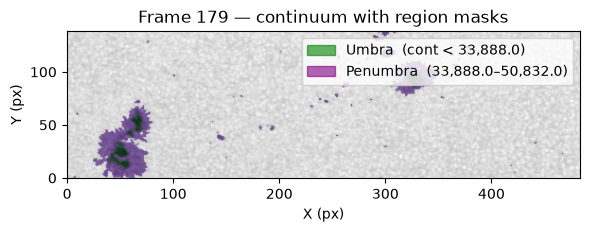

In [3]:
plot_calibration_frame(data, frame_idx=None, save=False, plots_dir=plots_dir)

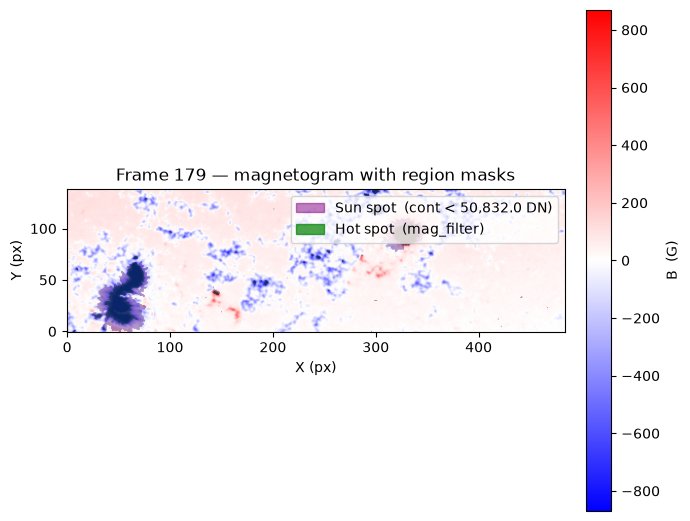

In [4]:
plot_magnetogram_masks(data, frame_idx=None, save=False, plots_dir=plots_dir)

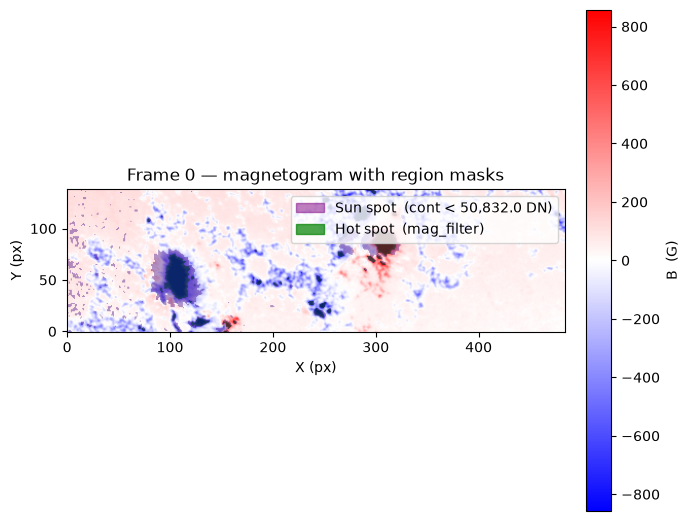

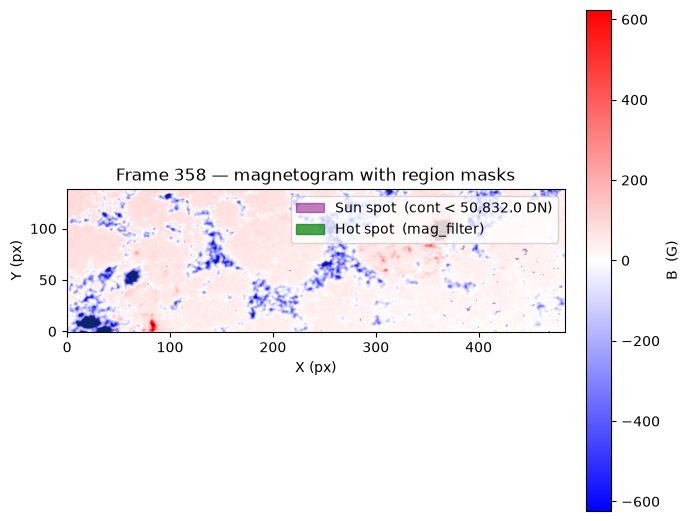

In [5]:
# First and last frame — does the mask still track the spot at the end of the window?
for idx in (0, data['n_t'] - 1):
    plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

## Step 3 — Per-frame metrics

`compute_metrics` returns the mean magnetogram and Doppler velocity per region per frame.
Because `data['hot_spot']` is present it also returns **`mean_mag_hotspot`** and
`area_hotspot` (magnetogram only — a hot spot has no separate Doppler meaning).

**Read the two B columns together.** `compute_metrics` averages *signed* `B_los`, so a
bipolar group cancels against itself: NOAA 11536's hot spot is 27% positive and 73%
negative, which drags its signed mean (−348 G) to under half its actual `|B|` (819 G).
That matters for a pulsation search, because the signed mean can move simply because the
polarity balance moved — a change in which pixels are in the mask, not a change in field
strength. The `|B|` column is there to tell those apart.

The hot-spot mean should otherwise fall between the umbral and penumbral means: it is the
strong-field core, which spans parts of both.

In [6]:
metrics = compute_metrics(data)

print(f'{region_dir.name}\n')
print('  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)')
rows = [
    ('Umbra',     'mean_mag_umb',     'mean_dop_umb',   'area_umb',     'umbra'),
    ('Penumbra',  'mean_mag_pen',     'mean_dop_pen',   'area_pen',     'penumbra'),
    ('Both',      'mean_mag_both',    'mean_dop_both',  'area_both',    'both'),
    ('Hot spot',  'mean_mag_hotspot', None,             'area_hotspot', 'hot_spot'),
    ('Quiet Sun', 'mean_mag_quiet',   'mean_dop_quiet', None,           None),
]
for label, mag_key, dop_key, area_key, mask_key in rows:
    if mag_key not in metrics:
        continue
    mag   = f'{np.nanmean(metrics[mag_key]):10.1f}'
    unsig = (f'{np.nanmean(np.abs(data["cube_mag"][data[mask_key]])):11.1f}'
             if mask_key else f'{"—":>11s}')
    dop   = f'{np.nanmean(metrics[dop_key]):12.1f}' if dop_key else f'{"—":>12s}'
    area  = f'{np.nanmean(metrics[area_key]):13.0f}' if area_key else f'{"—":>13s}'
    print(f'  {label:12s} {mag} {unsig} {dop} {area}')

# Velocities are absolute, so the physically meaningful number is the umbra relative to
# the quiet sun — suppressed convection in the umbra should leave it redshifted.
rel = np.nanmean(metrics['mean_dop_umb']) - np.nanmean(metrics['mean_dop_quiet'])
print(f'\n  umbra − quiet sun : {rel:+.1f} m/s')

# Polarity balance. compute_metrics averages *signed* B, so a bipolar group cancels
# against itself and the reported mean understates the real field — for NOAA 11536 the
# hot spot is 27% positive / 73% negative, and its signed mean (-348 G) is less than half
# its |B| (819 G). Compare the two columns above before reading anything into a trend:
# a change in the mean can be the polarity balance shifting rather than the field.
for label, mask_key in [('Umbra', 'umbra'), ('Hot spot', 'hot_spot')]:
    vals = data['cube_mag'][data[mask_key]]
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        continue
    frac_pos = 100 * (vals > 0).sum() / vals.size
    print(f'  {label:10s} polarity  {frac_pos:5.1f}% positive / {100 - frac_pos:5.1f}% negative'
          + ('   <- mixed, signed mean is cancelling' if 5 < frac_pos < 95 else ''))

NOAA_11536_2012-07-31

  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)
  Umbra            -316.8      1051.7        -14.1           485
  Penumbra         -213.4       446.7       -107.8          2459
  Both             -228.9       546.4        -92.4          2943
  Hot spot         -335.1       826.9            —          1532
  Quiet Sun          -0.0           —       -229.3             —

  umbra − quiet sun : +215.2 m/s
  Umbra      polarity   30.2% positive /  69.8% negative   <- mixed, signed mean is cancelling
  Hot spot   polarity   26.4% positive /  73.6% negative   <- mixed, signed mean is cancelling


## Step 4 — Time series

`plot_time_series` draws mean B (top) and mean v (bottom) for umbra, penumbra, both and
quiet sun, with the **hot spot** added to the magnetogram panel in orange.

`subtract_quiet=True` re-references everything to the quiet sun, which is the right view
for the velocities given the residual HMI bias. `normalized=True` min-max scales each
series, useful for comparing the *shape* of the B and v variations rather than their size.

`plot_area` is the sanity check that belongs beside them: a mean that moves while its area
also moves is a segmentation artefact, not a measurement.

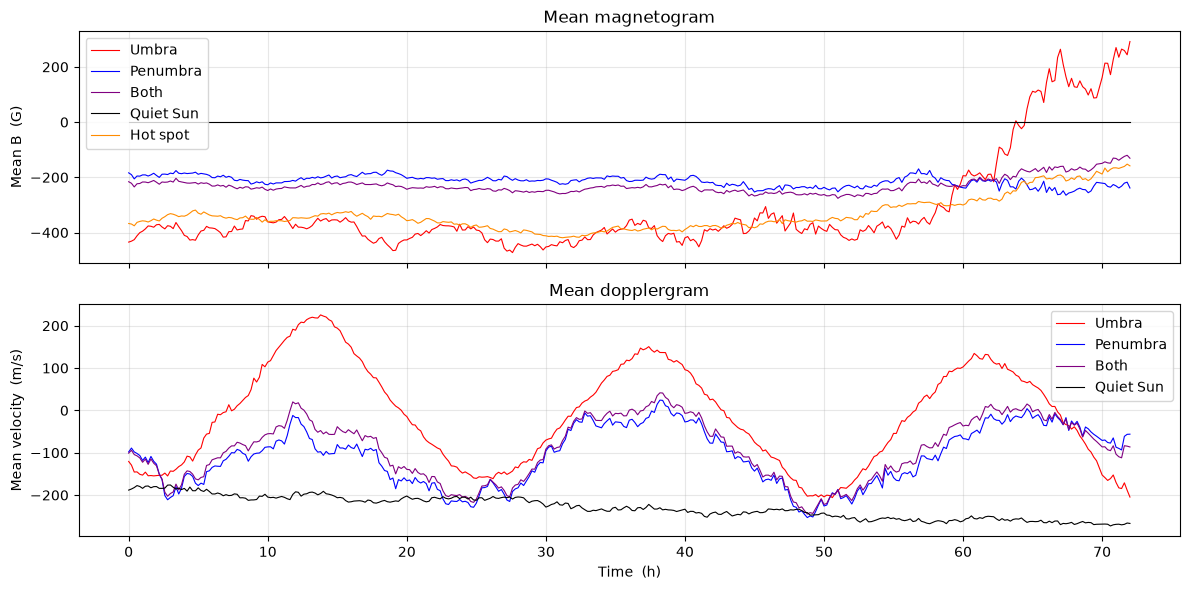

In [7]:
plot_time_series(data, metrics, save=False, plots_dir=plots_dir)

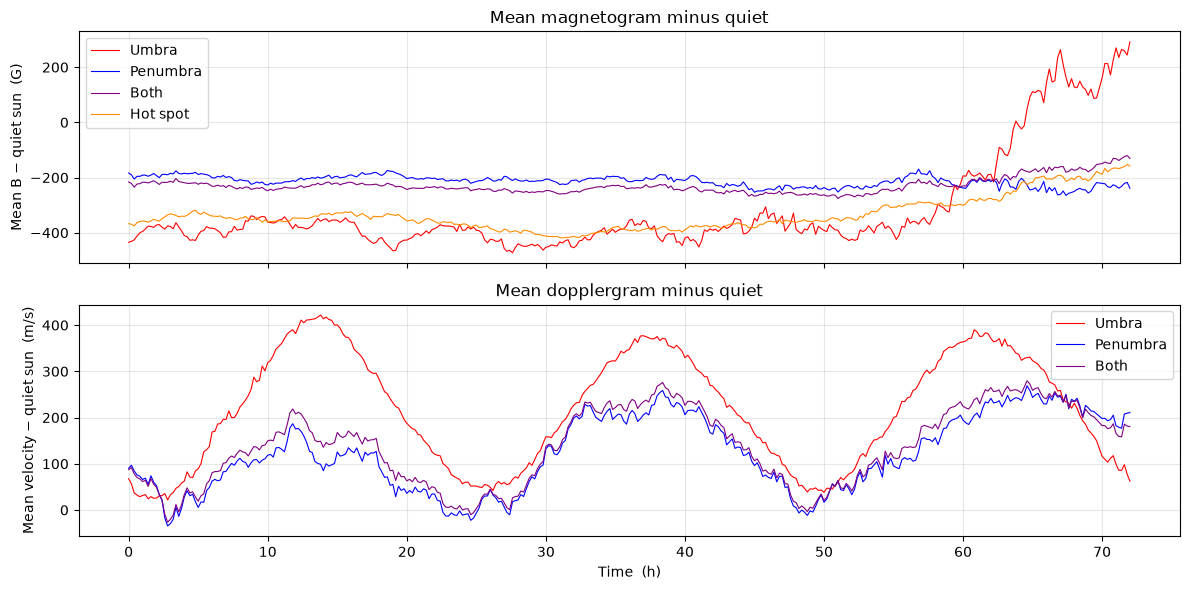

In [8]:
plot_time_series(data, metrics, subtract_quiet=True, save=False, plots_dir=plots_dir)

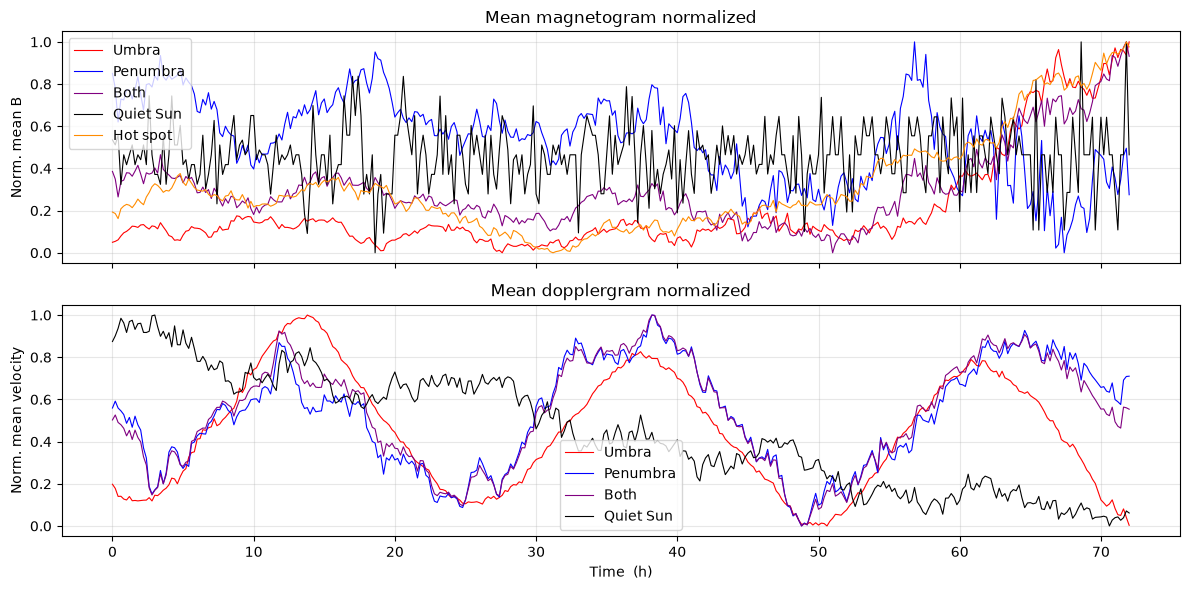

In [9]:
plot_time_series(data, metrics, normalized=True, save=False, plots_dir=plots_dir)

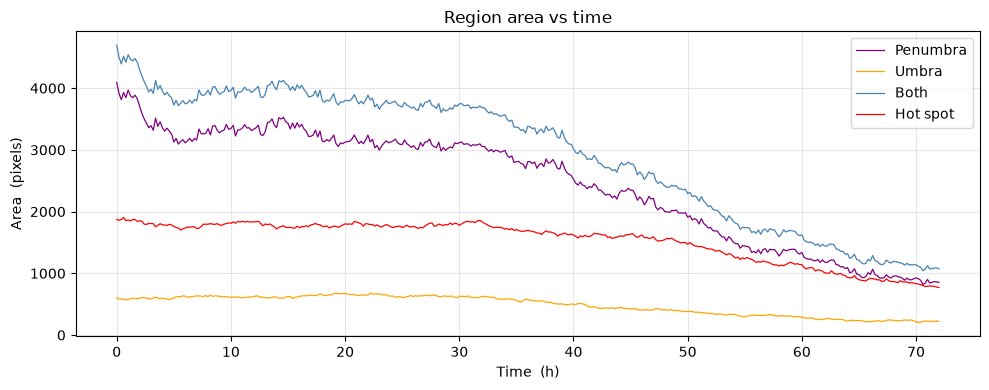

In [10]:
plot_area(data, metrics, save=False, plots_dir=plots_dir)

## Step 5 — HTML animation

A 3-panel continuum / magnetogram / dopplergram movie with the umbra and penumbra
outlined, written to `anim.html` in the region's processed directory and openable in any
browser.

`step` subsamples frames — the whole point is to keep the embedded file manageable, so
raise it for long windows. At 720 s cadence `step=5` is one frame per hour.

In [11]:
anim_path = region_dir / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = max(1, data['n_t'] // 60),   # ~60 frames regardless of window length
    fps       = 5,
    mag_symmetric_cbar = True,
)

Animation saved → ../data/processed/NOAA_11536_2012-07-31/anim.html  (72 frames, 29.5 MB)


In [12]:
# Open the saved animation in the browser
from IPython.display import FileLink

FileLink(str(anim_path))

/mnt/shared/Projects/sun_spots_pulsation_review/data/processed/NOAA_11536_2012-07-31/anim.html

## All regions — comparison

One row per processed region, so the Löptien sample can be read side by side without
stepping through each one. Velocities are quoted relative to that region's own quiet sun,
since the absolute HMI bias differs between regions.

In [13]:
print(f'{"region":28s} {"n_t":>5s} {"span":>7s} {"B umb":>9s} {"B hot":>9s} '
      f'{"v umb−qs":>10s} {"area umb":>9s}')
print('-' * 84)

all_metrics = {}
for r in regions:
    d = load_noaa_region(r)
    m = compute_metrics(d)
    all_metrics[r.name] = (d, m)
    v_rel = np.nanmean(m['mean_dop_umb']) - np.nanmean(m['mean_dop_quiet'])
    b_hot = np.nanmean(m['mean_mag_hotspot']) if 'mean_mag_hotspot' in m else np.nan
    print(f"{r.name:28s} {d['n_t']:5d} {d['time_h'][-1]:6.1f}h "
          f"{np.nanmean(m['mean_mag_umb']):9.1f} {b_hot:9.1f} "
          f"{v_rel:+10.1f} {np.nanmean(m['area_umb']):9.0f}")

region                         n_t    span     B umb     B hot   v umb−qs  area umb
------------------------------------------------------------------------------------
NOAA_11536_2012-07-31          359   72.0h    -316.8    -335.1     +215.2       485


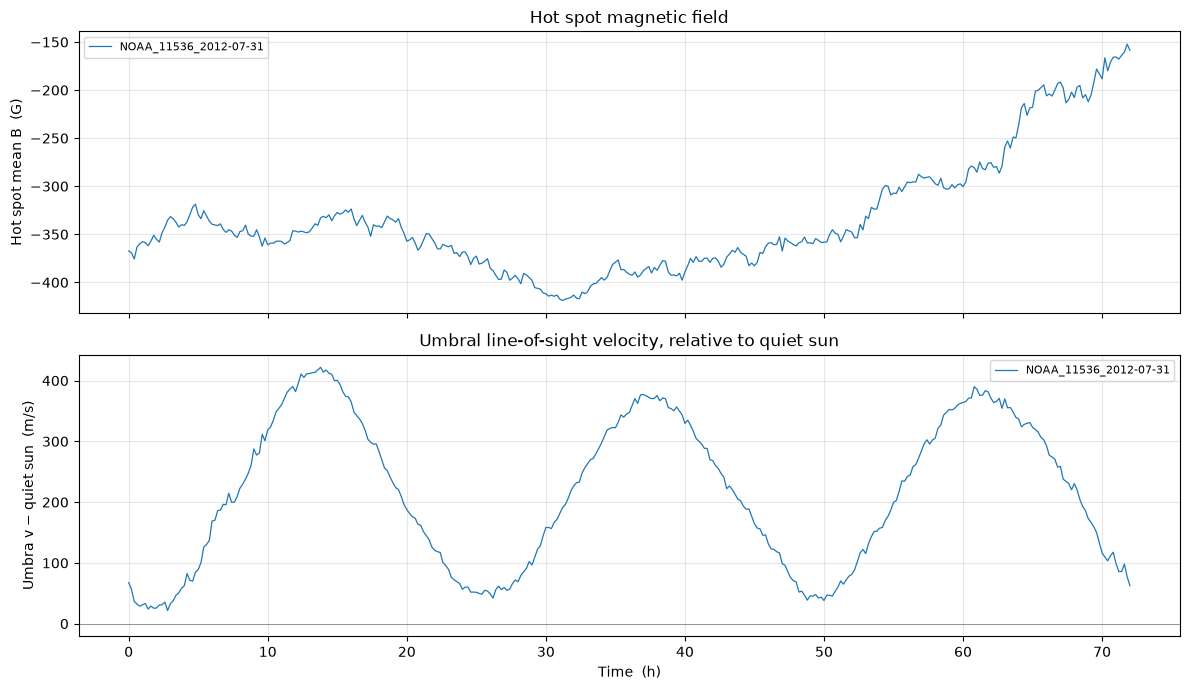

In [14]:
# Mean B in the hot spot for every region, on one axis. Each region is plotted against its
# own elapsed time, so this compares the shape of the variation, not absolute epochs.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for name, (d, m) in all_metrics.items():
    if 'mean_mag_hotspot' in m:
        ax1.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.9, label=name)
    ax2.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.9, label=name)

ax1.set_ylabel('Hot spot mean B  (G)')
ax1.set_title('Hot spot magnetic field')
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

ax2.set_ylabel('Umbra v − quiet sun  (m/s)')
ax2.set_xlabel('Time  (h)')
ax2.set_title('Umbral line-of-sight velocity, relative to quiet sun')
ax2.axhline(0, color='black', lw=0.5, alpha=0.5)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()